# Reference-Guided Slice-wise XY Translation Registration

`reference/lif_pipeline.py`의 rigid registration 알고리즘을 그대로 사용합니다.

- fixed image: 이미 보정된 `Reference`의 `Z=k-1` slice
- moving image: raw 또는 denoised `Reference`의 `Z=k` slice
- transform: 2D translation only
- optimizer/metric: SimpleITK `ImageRegistrationMethod`, mean-squares, regular-step gradient descent, multi-resolution pyramid
- 같은 transform을 `DAPI`, `Reference`, `Target`의 동일 Z slice에 함께 적용합니다.

## 0. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import datetime
import importlib
import json
import os
import sys
from collections import defaultdict

PROJECT_DIR = Path.cwd()
MPLCONFIGDIR = PROJECT_DIR / ".matplotlib"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

DATA_DIR = PROJECT_DIR / "data"
REFERENCE_DIR = PROJECT_DIR / "reference"
if str(REFERENCE_DIR) not in sys.path:
    sys.path.insert(0, str(REFERENCE_DIR))

import lif_pipeline
importlib.reload(lif_pipeline)

from lif_pipeline import (
    SeriesData,
    discover_tiff_series,
    ensure_uint16,
    generate_lif_report,
    load_series_from_tiff_dir,
    process_series,
    sanitize_name,
)

CHANNEL_LABELS = ("DAPI", "Reference", "Target")
REFERENCE_LABEL = "Reference"

USE_DENOISED_STACKS_IF_AVAILABLE = True
RUN_REGISTRATION = True
SAVE_REGISTERED_STACKS = True
SAVE_GIF = True
SAVE_MIP = True
SAVE_TRANSFORM_CSV = True
SAVE_LIF_REPORTS = True

JUMP_THRESHOLD_VOXELS = 5.0
FATAL_JUMP_THRESHOLD_VOXELS = 10.0
SMOOTHING_SIGMA = 1.0
GIF_DURATION_PER_FRAME = 0.25

print({
    "project_dir": str(PROJECT_DIR),
    "data_dir": str(DATA_DIR),
    "reference_module": str(REFERENCE_DIR / "lif_pipeline.py"),
    "algorithm": "lif_pipeline.process_series -> register_volume_slice_by_slice",
    "use_denoised_if_available": USE_DENOISED_STACKS_IF_AVAILABLE,
})

Matplotlib is building the font cache; this may take a moment.


{'project_dir': '/Volumes/jihyeonpark/260429', 'data_dir': '/Volumes/jihyeonpark/260429/data', 'reference_module': '/Volumes/jihyeonpark/260429/reference/lif_pipeline.py', 'algorithm': 'lif_pipeline.process_series -> register_volume_slice_by_slice', 'use_denoised_if_available': True}


## 1. Series Discovery

In [2]:
def discover_registration_series(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    rows = []
    for series_dir in discover_tiff_series(data_dir, channel_labels=CHANNEL_LABELS):
        denoised_path = series_dir / "denoised_stacks" / f"{sanitize_name(series_dir.name)}_stack_denoised.tif"
        rows.append({
            "lif_name": series_dir.parent.name,
            "series_name": series_dir.name,
            "series_dir": series_dir,
            "raw_stacks_dir": series_dir / "stacks",
            "denoised_stack_path": denoised_path if denoised_path.exists() else None,
            "registration_input": "denoised" if USE_DENOISED_STACKS_IF_AVAILABLE and denoised_path.exists() else "raw",
            "registered_stacks_dir": series_dir / "registered_stacks",
        })
    return pd.DataFrame(rows)

series_df = discover_registration_series()
display(series_df)

,lif_name,series_name,series_dir,raw_stacks_dir,denoised_stack_path,registration_input,registered_stacks_dir
0,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
1,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_2,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
2,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_3,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
3,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_FiX ITS_1,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
4,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_FiX ITS_2,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
5,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_FiX ITS_3,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
6,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_MultiExR_1,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
7,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_MultiExR_2,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
8,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_MultiExR_3,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,denoised,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
9,2_gephyrin Ms BD_Nlgn2 Rb SYSY,DIW_63x_FiXITS_1,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,denoised,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...


## 2. Loading Helpers

In [3]:
def load_denoised_series(series_dir: Path, channel_labels: tuple[str, ...] = CHANNEL_LABELS) -> SeriesData | None:
    series_dir = Path(series_dir)
    stack_path = series_dir / "denoised_stacks" / f"{sanitize_name(series_dir.name)}_stack_denoised.tif"
    if not stack_path.exists():
        return None

    try:
        arr = tifffile.imread(str(stack_path))
    except Exception as exc:
        print(f"[WARN] Could not read denoised stack, falling back to raw stacks: {stack_path} ({exc})")
        return None
    if arr.ndim != 4 or arr.shape[1] != len(channel_labels):
        print(f"[WARN] Unexpected denoised stack shape {arr.shape}, falling back to raw stacks: {stack_path}")
        return None

    stacks = {label: ensure_uint16(arr[:, i, :, :]) for i, label in enumerate(channel_labels)}

    metadata_path = series_dir / "metadata.json"
    preprocessing_metadata_path = series_dir / "preprocessing_metadata.json"
    if metadata_path.exists():
        with open(metadata_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)
    else:
        z, y, x = next(iter(stacks.values())).shape
        metadata = {
            "lif_name": series_dir.parent.name,
            "series_name": series_dir.name,
            "series_index": -1,
            "x_size": x,
            "y_size": y,
            "z_slices": z,
            "channels": len(channel_labels),
            "channel_labels": list(channel_labels),
            "source": "denoised_tiff",
            "source_path": str(stack_path),
        }
    if preprocessing_metadata_path.exists():
        with open(preprocessing_metadata_path, "r", encoding="utf-8") as f:
            preprocessing_metadata = json.load(f)
        metadata["preprocessing"] = preprocessing_metadata.get("preprocessing", metadata.get("preprocessing", {}))

    metadata["source"] = "denoised_tiff"
    metadata["source_path"] = str(stack_path)

    return SeriesData(
        lif_name=metadata.get("lif_name", series_dir.parent.name),
        series_name=metadata.get("series_name", series_dir.name),
        series_index=metadata.get("series_index", -1) or -1,
        stacks=stacks,
        metadata=metadata,
    )


def load_registration_series(series_dir: Path, use_denoised_if_available: bool = USE_DENOISED_STACKS_IF_AVAILABLE) -> tuple[SeriesData | None, str]:
    if use_denoised_if_available:
        denoised = load_denoised_series(series_dir, channel_labels=CHANNEL_LABELS)
        if denoised is not None:
            return denoised, "denoised"
    return load_series_from_tiff_dir(series_dir, channel_labels=CHANNEL_LABELS), "raw"


def transform_log_to_df(series: SeriesData, transform_log: list[dict], input_source: str) -> pd.DataFrame:
    rows = []
    for item in transform_log:
        rows.append({
            "lif_name": series.lif_name,
            "series_name": series.series_name,
            "input_source": input_source,
            "z": item.get("z"),
            "tx": item.get("tx"),
            "ty": item.get("ty"),
            "shift_magnitude": float(np.hypot(item.get("tx", 0.0), item.get("ty", 0.0))),
            "reason": item.get("reason"),
        })
    return pd.DataFrame(rows)

## 3. Run Registration and Reference Outputs

In [4]:
registration_results = []
transform_tables = []
series_results_by_lif = defaultdict(list)
run_timestamp = datetime.datetime.now().isoformat(timespec="seconds")

if not RUN_REGISTRATION:
    print("[SKIP] RUN_REGISTRATION=False")
elif series_df.empty:
    print(f"[SKIP] No stack series found under {DATA_DIR}")
else:
    for row in series_df.itertuples(index=False):
        series, input_source = load_registration_series(Path(row.series_dir))
        if series is None:
            print(f"[SKIP] Could not load {row.series_dir}")
            continue

        print(f"\n[REGISTER] {series.lif_name} :: {series.series_name} | input={input_source}")
        result = process_series(
            series=series,
            base_dir=DATA_DIR,
            channel_labels=CHANNEL_LABELS,
            jump_threshold_voxels=JUMP_THRESHOLD_VOXELS,
            fatal_jump_threshold=FATAL_JUMP_THRESHOLD_VOXELS,
            smoothing_sigma=SMOOTHING_SIGMA,
            denoise_lines=False,
            gif_duration_per_frame=GIF_DURATION_PER_FRAME,
            verbose=True,
            show_mip=False,
            save_raw_stacks_if_missing=False,
        )
        result["input_source"] = input_source
        series_results_by_lif[series.lif_name].append(result)

        transform_df = transform_log_to_df(series, result["transform_log"], input_source=input_source)
        transform_tables.append(transform_df)
        transform_csv_path = ""
        if SAVE_TRANSFORM_CSV and not transform_df.empty:
            transform_csv = result["series_dir"] / "registered_stacks" / "transform_parameters.csv"
            transform_csv.parent.mkdir(parents=True, exist_ok=True)
            transform_df.to_csv(transform_csv, index=False)
            transform_csv_path = str(transform_csv)

        registered_multichannel_stack_path = (
            result["series_dir"] / "registered_stacks" / f"{sanitize_name(series.series_name)}_stack_registered.tif"
        )
        actual_z = result["registered_stacks"][CHANNEL_LABELS[0]].shape[0]
        original_z = series.stacks[CHANNEL_LABELS[0]].shape[0]
        registration_results.append({
            "lif_name": series.lif_name,
            "series_name": series.series_name,
            "input_source": input_source,
            "original_z_slices": original_z,
            "final_z_slices": actual_z,
            "clipped_due_to_failure": actual_z < original_z,
            "n_transforms": len(result["transform_log"]),
            "series_dir": str(result["series_dir"]),
            "registered_stacks_dir": str(result["series_dir"] / "registered_stacks"),
            "registered_multichannel_stack_path": str(registered_multichannel_stack_path),
            "gif_path": str(result["gif_path"]),
            "mip_path": str(result["mip_path"]),
            "transform_csv_path": transform_csv_path,
        })

report_results = []
if SAVE_LIF_REPORTS and series_results_by_lif:
    for lif_name, lif_results in series_results_by_lif.items():
        lif_dir = DATA_DIR / sanitize_name(lif_name)
        print(f"\n[REPORT] {lif_name} ({len(lif_results)} series)")
        report = generate_lif_report(
            lif_name=lif_name,
            lif_dir=lif_dir,
            series_results=lif_results,
            run_timestamp=run_timestamp,
            source_path=None,
        )
        report_results.append({
            "lif_name": lif_name,
            "csv_path": str(report["csv_path"]),
            "pdf_path": str(report["pdf_path"]),
            "n_denoise_pngs": len(report.get("denoise_png_paths", [])),
        })

results_df = pd.DataFrame(registration_results)
transform_parameters_df = pd.concat(transform_tables, ignore_index=True) if transform_tables else pd.DataFrame()
reports_df = pd.DataFrame(report_results)
display(results_df)
display(transform_parameters_df)
display(reports_df)



[REGISTER] 1_PSD Ms MA1046_Homer Rb SYSY :: DIW_63X_panExM-t_1 | input=denoised

[PROCESS] 1_PSD Ms MA1046_Homer Rb SYSY :: DIW_63X_panExM-t_1
   [INFO] Registering 60 slices sequentially (fixed = registered[k-1], moving = raw[k])
   [INFO] Registration complete (60 slices, Z=0 anchor).
   [SAVE] GIF -> /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/GIFS/DIW_63X_panExM-t_1_sidebyside.gif
   [SAVE] MIP -> /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/MIP/DIW_63X_panExM-t_1_registered_MIP.png

[REGISTER] 1_PSD Ms MA1046_Homer Rb SYSY :: DIW_63X_panExM-t_2 | input=denoised

[PROCESS] 1_PSD Ms MA1046_Homer Rb SYSY :: DIW_63X_panExM-t_2
   [INFO] Registering 57 slices sequentially (fixed = registered[k-1], moving = raw[k])
   [INFO] Registration complete (57 slices, Z=0 anchor).
   [SAVE] GIF -> /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_2/GIFS/DIW_63X_panExM-t_2_sidebyside.gif
   [S

,lif_name,series_name,input_source,original_z_slices,final_z_slices,clipped_due_to_failure,n_transforms,series_dir,registered_stacks_dir,registered_multichannel_stack_path,gif_path,mip_path,transform_csv_path
0,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,denoised,61,61,False,61,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
1,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_2,denoised,58,58,False,58,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
2,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_3,denoised,34,34,False,34,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
3,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_FiX ITS_1,denoised,28,28,False,28,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
4,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_FiX ITS_2,denoised,60,60,False,60,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
5,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_FiX ITS_3,denoised,52,52,False,52,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
6,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_MultiExR_1,denoised,57,57,False,57,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
7,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_MultiExR_2,denoised,33,27,True,28,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
8,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63x_MultiExR_3,denoised,57,57,False,57,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...
9,2_gephyrin Ms BD_Nlgn2 Rb SYSY,DIW_63x_FiXITS_1,denoised,45,45,False,45,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...


,lif_name,series_name,input_source,z,tx,ty,shift_magnitude,reason
0,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,denoised,0,0.000000,0.000000,0.000000,anchor
1,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,denoised,1,0.085473,-0.432102,0.440474,ok
2,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,denoised,2,0.138091,-0.865077,0.876029,ok
3,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,denoised,3,0.282592,-1.088005,1.124106,ok
4,1_PSD Ms MA1046_Homer Rb SYSY,DIW_63X_panExM-t_1,denoised,4,0.170188,-1.363034,1.373618,ok
...,...,...,...,...,...,...,...,...
888,2_gephyrin Ms BD_Nlgn2 Rb SYSY,DIW_63x_panExM-t_3,denoised,31,-4.514119,-3.339469,5.615098,ok
889,2_gephyrin Ms BD_Nlgn2 Rb SYSY,DIW_63x_panExM-t_3,denoised,32,-4.351574,-3.359715,5.497625,ok
890,2_gephyrin Ms BD_Nlgn2 Rb SYSY,DIW_63x_panExM-t_3,denoised,33,-4.529658,-3.314403,5.612760,ok
891,2_gephyrin Ms BD_Nlgn2 Rb SYSY,DIW_63x_panExM-t_3,denoised,34,-4.618091,-3.311506,5.682678,ok


,lif_name,csv_path,pdf_path,n_denoise_pngs
0,1_PSD Ms MA1046_Homer Rb SYSY,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,/Volumes/jihyeonpark/260429/data/1_PSD Ms MA10...,0
1,2_gephyrin Ms BD_Nlgn2 Rb SYSY,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,/Volumes/jihyeonpark/260429/data/2_gephyrin Ms...,0


## 4. Transform Diagnostics

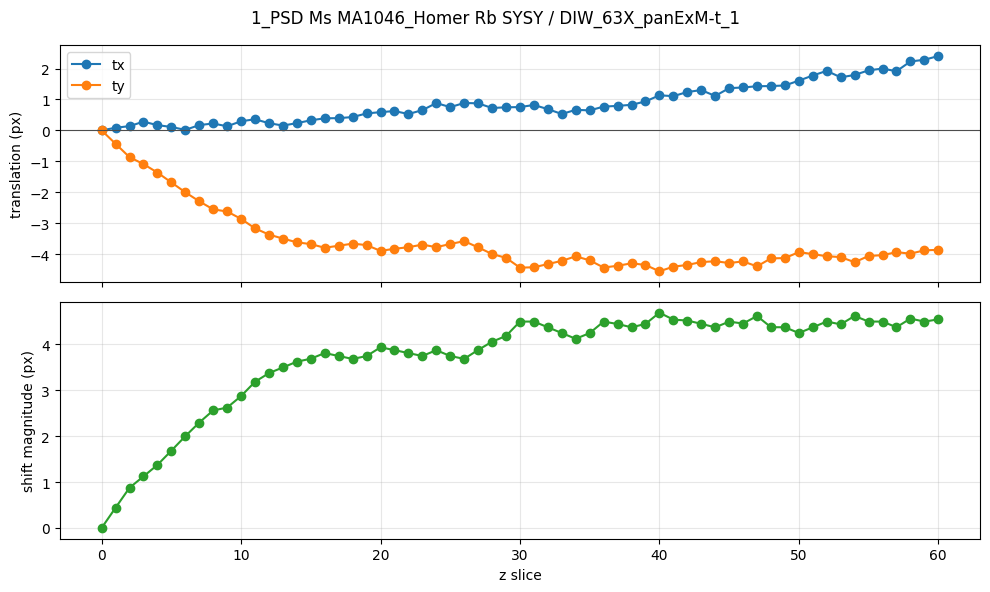

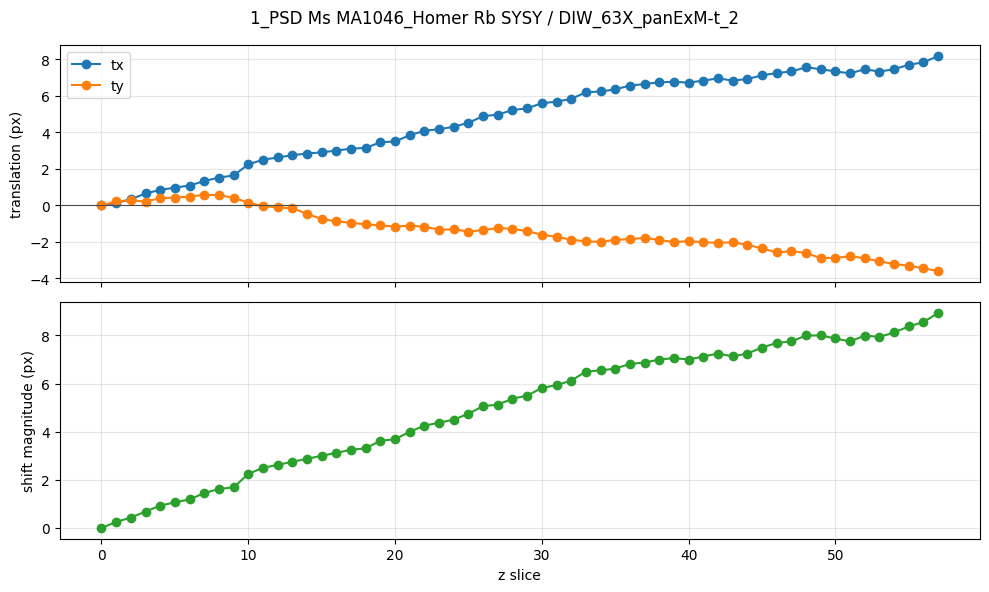

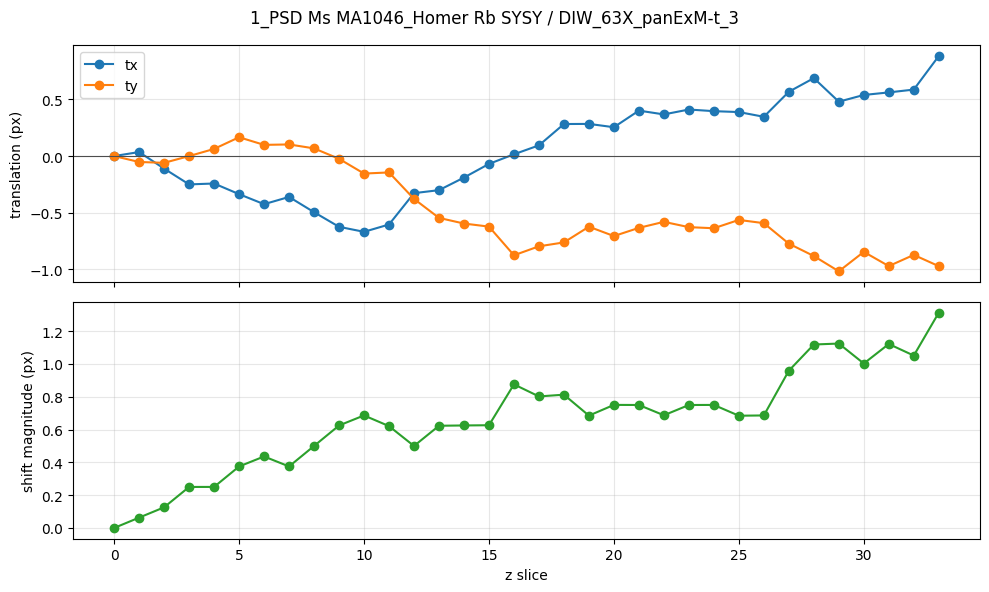

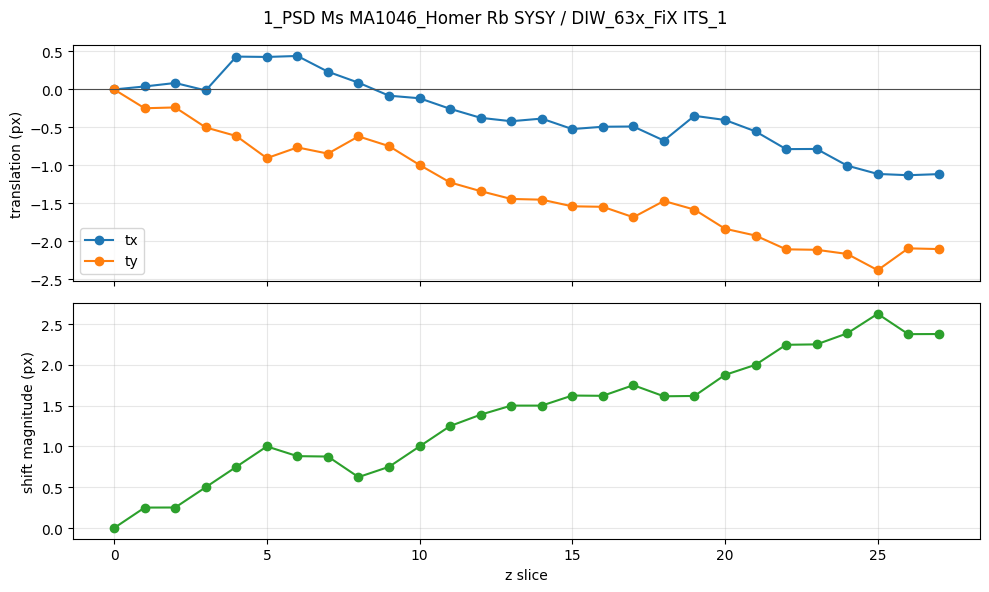

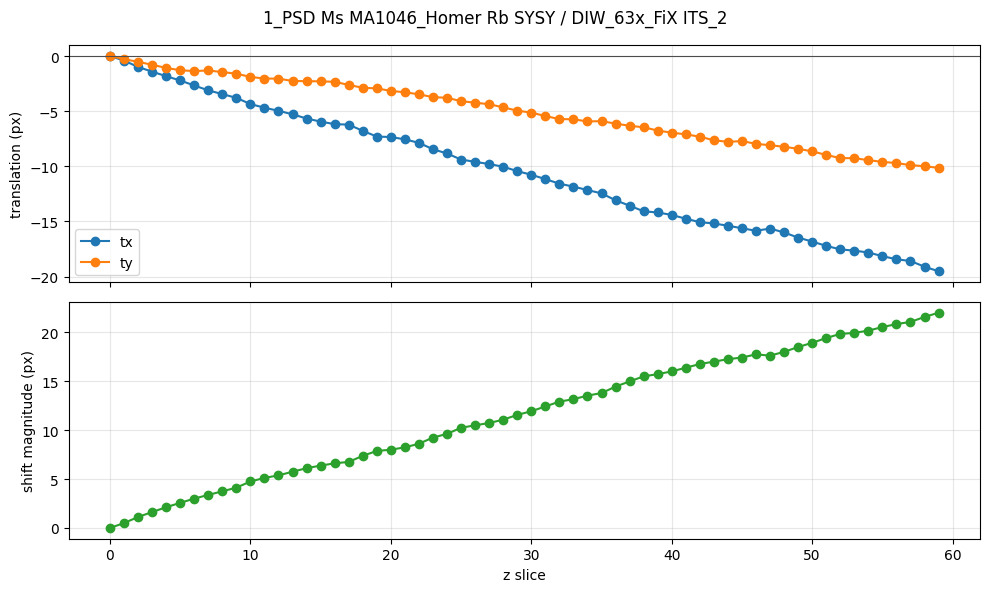

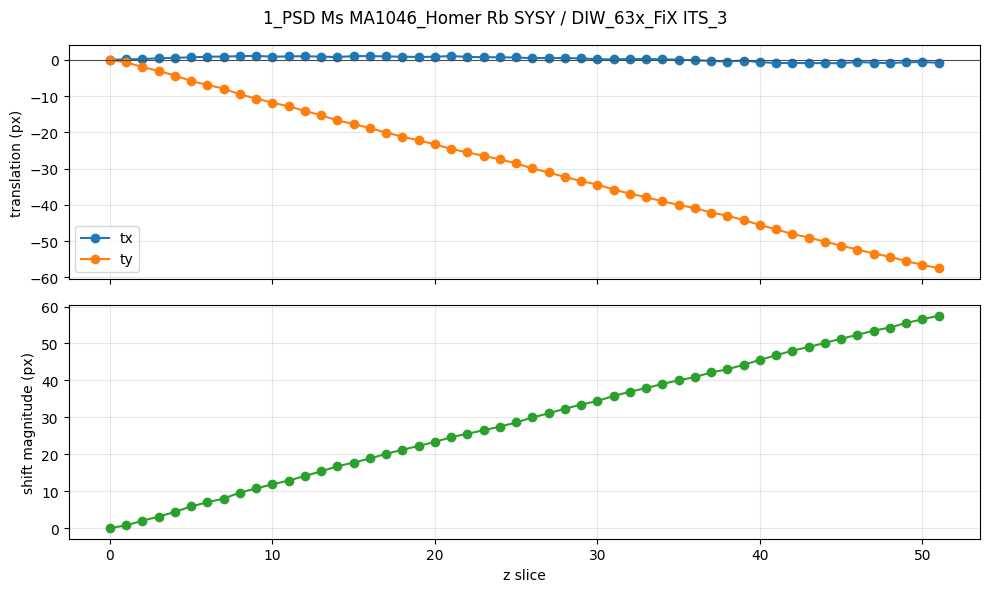

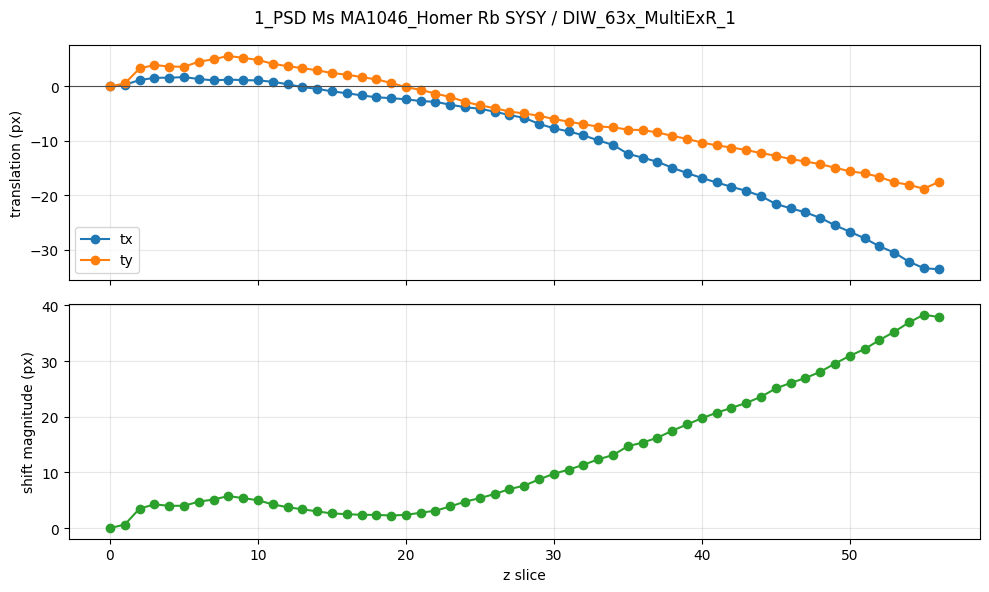

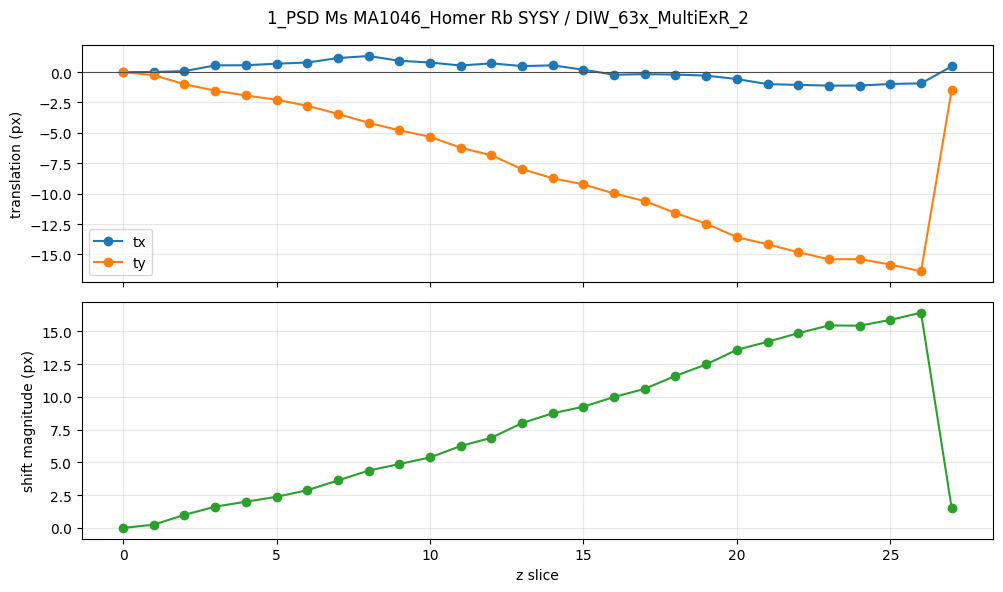

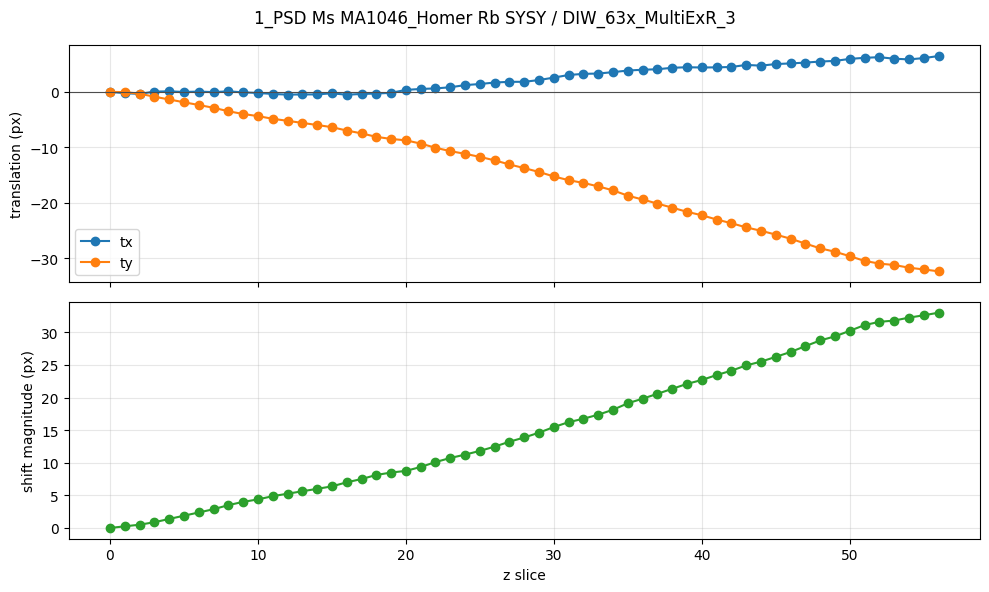

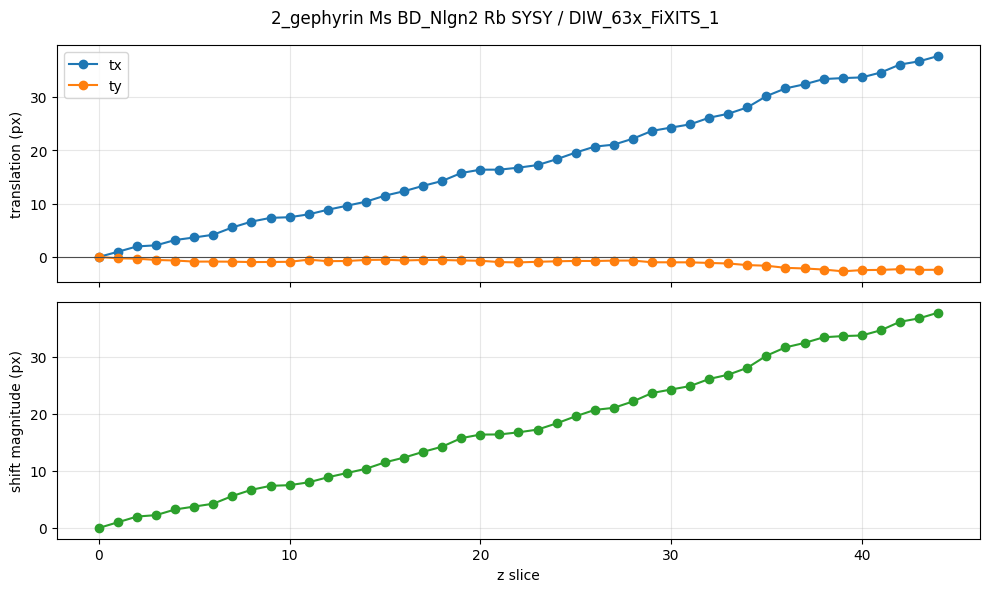

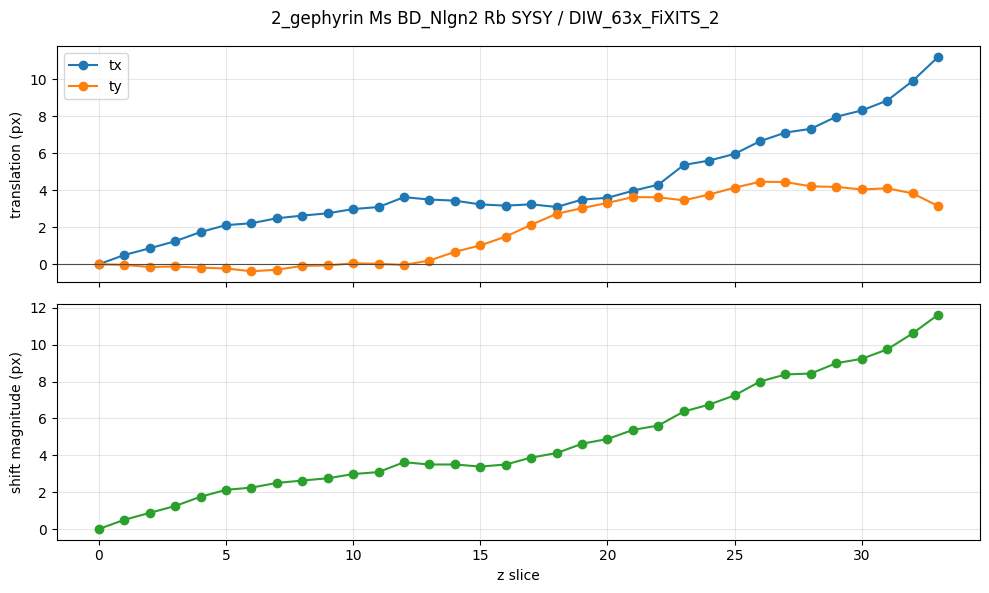

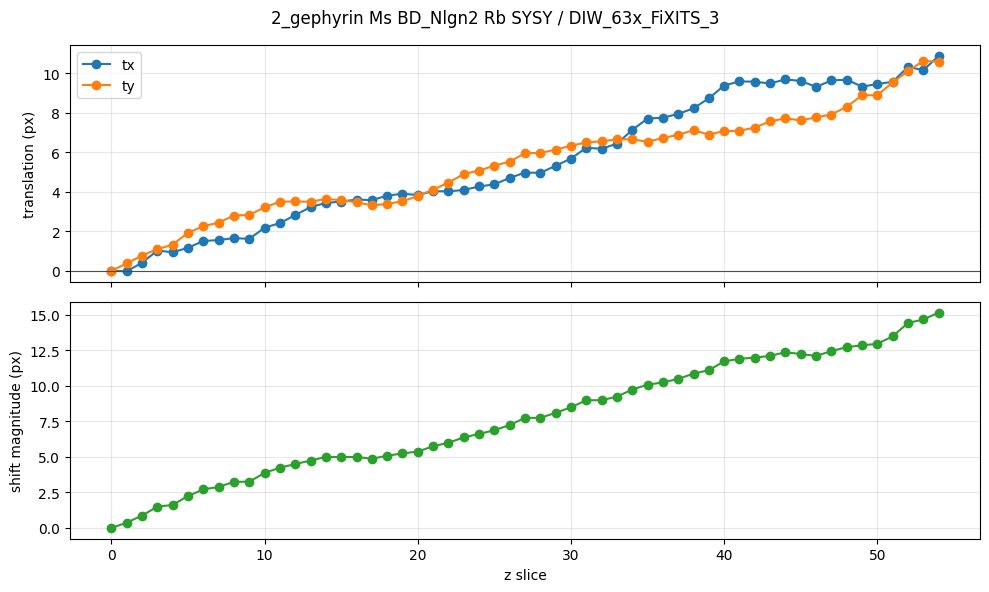

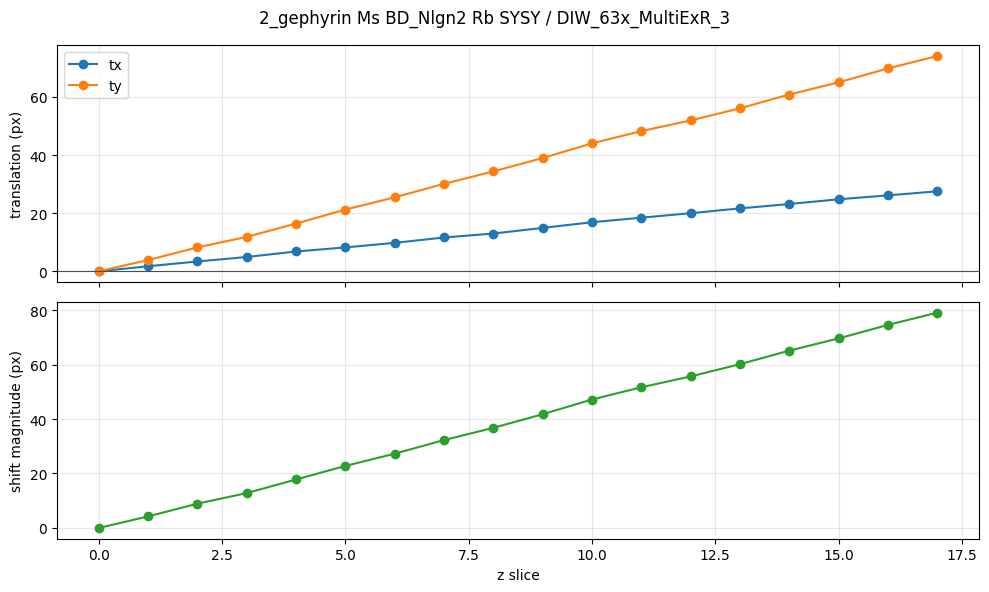

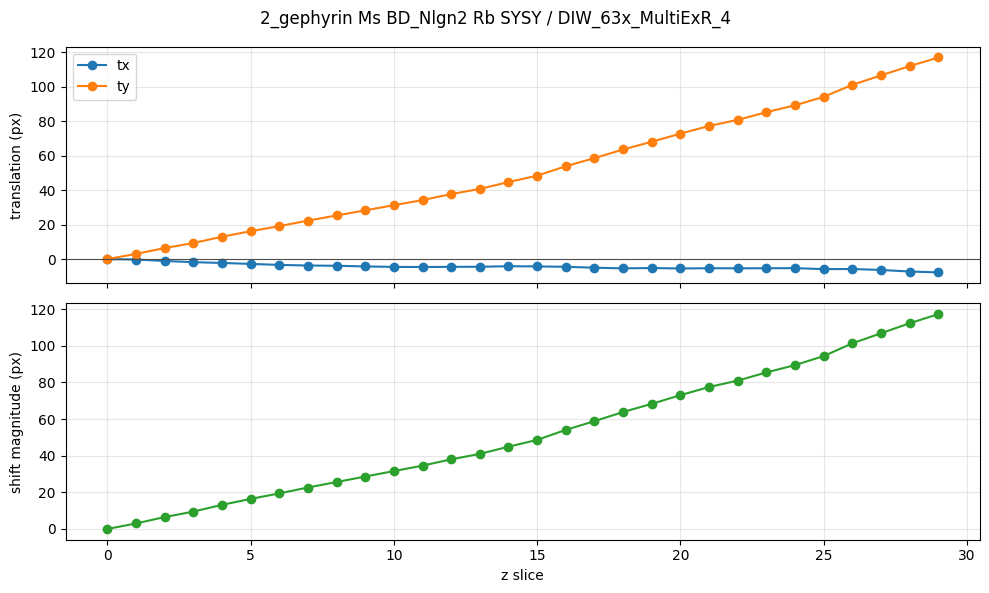

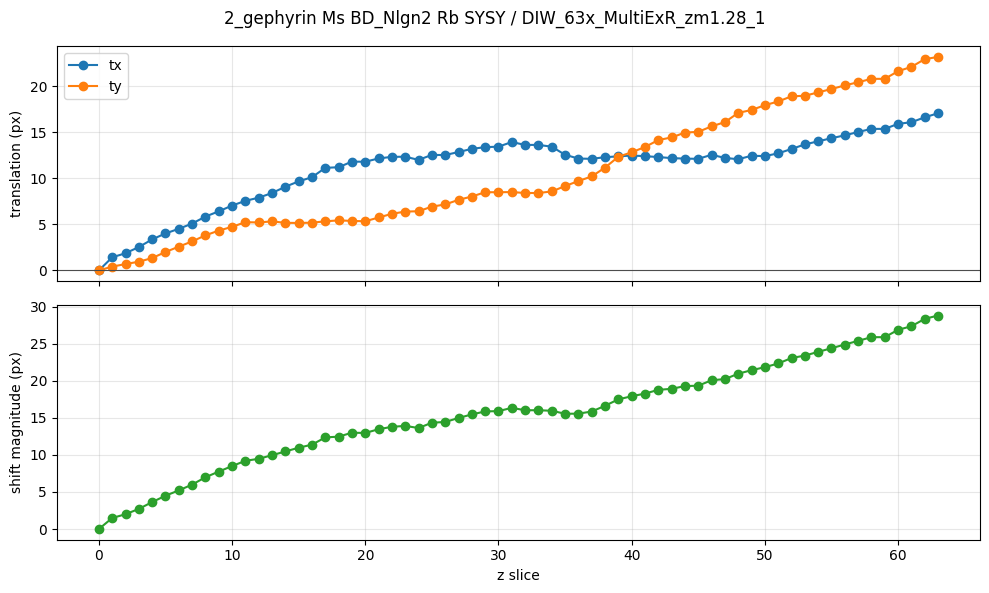

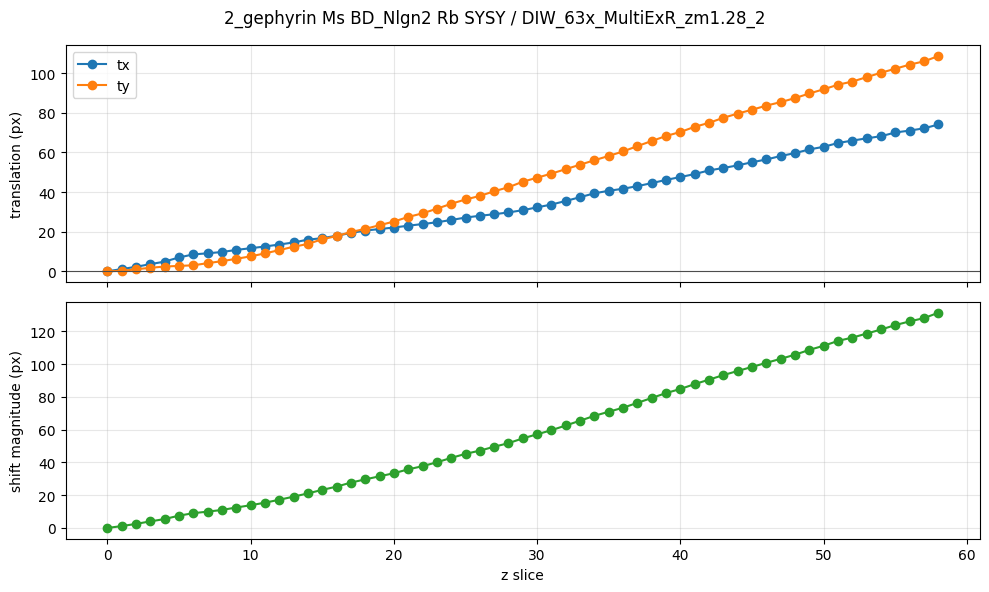

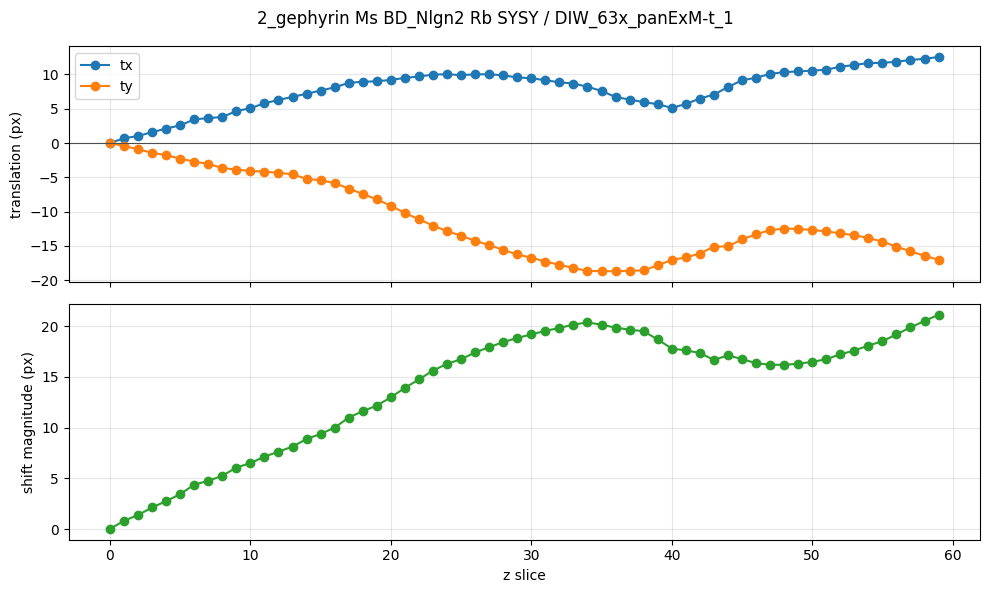

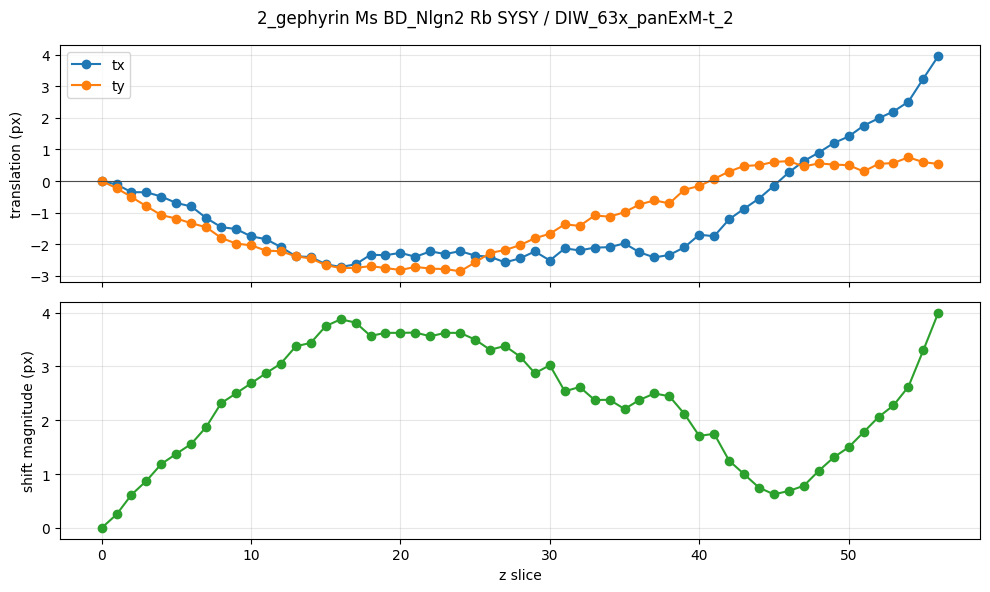

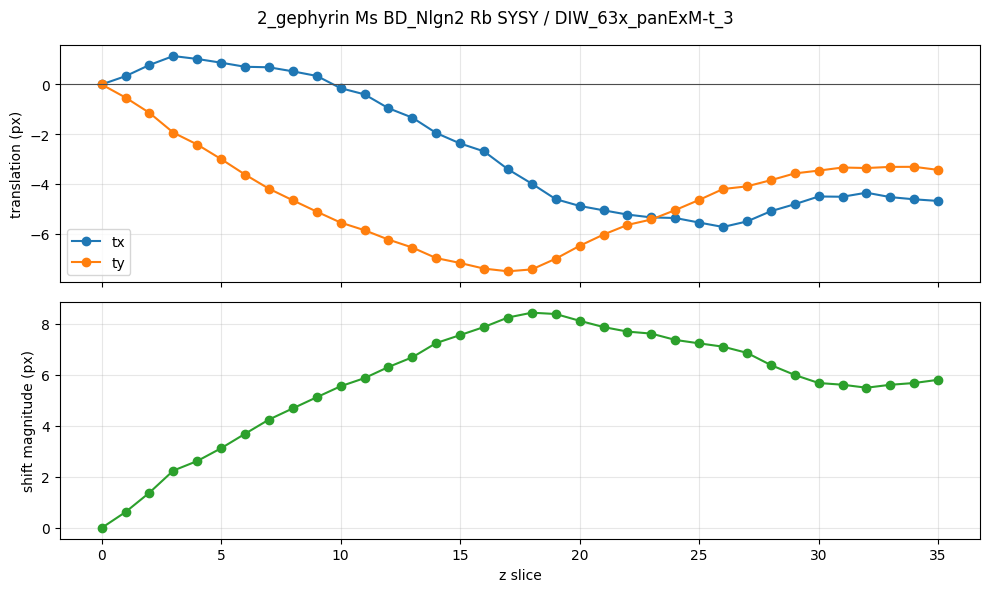

In [5]:
if "transform_parameters_df" not in globals() or transform_parameters_df.empty:
    print("No transform parameters to plot.")
else:
    for (lif_name, series_name), group in transform_parameters_df.groupby(["lif_name", "series_name"], sort=False):
        group = group.sort_values("z")
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        fig.suptitle(f"{lif_name} / {series_name}")
        axes[0].plot(group["z"], group["tx"], marker="o", label="tx")
        axes[0].plot(group["z"], group["ty"], marker="o", label="ty")
        axes[0].axhline(0, color="0.3", linewidth=0.8)
        axes[0].set_ylabel("translation (px)")
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        axes[1].plot(group["z"], group["shift_magnitude"], marker="o", color="tab:green")
        axes[1].set_xlabel("z slice")
        axes[1].set_ylabel("shift magnitude (px)")
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## 5. Output Summary

In [6]:
if "results_df" in globals() and not results_df.empty:
    print("Registration outputs written:")
    for result in results_df.itertuples(index=False):
        print(f"- {result.lif_name}/{result.series_name} | input={result.input_source}")
        print(f"  registered_stacks: {result.registered_stacks_dir}")
        print(f"  multichannel stack: {result.registered_multichannel_stack_path}")
        print(f"  gif: {result.gif_path}")
        print(f"  mip: {result.mip_path}")
        print(f"  transforms: {result.transform_csv_path}")
else:
    print("No registration outputs were generated.")

if "reports_df" in globals() and not reports_df.empty:
    print("\nReference-style report outputs written:")
    for report in reports_df.itertuples(index=False):
        print(f"- {report.lif_name}")
        print(f"  csv: {report.csv_path}")
        print(f"  pdf: {report.pdf_path}")


Registration outputs written:
- 1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1 | input=denoised
  registered_stacks: /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/registered_stacks
  multichannel stack: /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/registered_stacks/DIW_63X_panExM-t_1_stack_registered.tif
  gif: /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/GIFS/DIW_63X_panExM-t_1_sidebyside.gif
  mip: /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/MIP/DIW_63X_panExM-t_1_registered_MIP.png
  transforms: /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_1/registered_stacks/transform_parameters.csv
- 1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_2 | input=denoised
  registered_stacks: /Volumes/jihyeonpark/260429/data/1_PSD Ms MA1046_Homer Rb SYSY/DIW_63X_panExM-t_2/registered_stacks
  multichannel stack: /Volumes/j